In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov

%load_ext autoreload
%autoreload 2

    


/tmp/ipykernel_3770270/4069794190.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
def get_samps(fname, acorr_max = 0.075, acorr_min = 0.0):
    df = pk.load(open(fname,'rb'))
    sig8 = df['sigma8']
    nchains = 64
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    print(len(ind_del))
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys





In [3]:
# # ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Feb/'
# # samps_all = get_MCsamps(ldir + 'mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps_gty = get_MCsamps(ldir + 'mcmc_v9_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps_xipm = get_MCsamps(ldir + 'mcmc_v9_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

# # samps, keys = get_samps(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

# # samps, keys = get_samps(ldir + 'mcmc_v10_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps, keys = get_samps(ldir + 'mcmc_v10_wide_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps, keys = get_samps(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# # samps, keys = get_samps(ldir + 'mcmc_v11_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps, keys = get_samps(ldir + 'mcmc_v11_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')


In [4]:
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# # df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2000_4000_num_chains_32.pkl','rb'))
# # df.keys()
# sig8 = df['sigma8']
# # nchains = 80
# nchains = 64
# sig8_rs = sig8.reshape(nchains,-1)
# # print(sig8_rs.shape)
# from numpyro.diagnostics import autocorrelation, autocovariance

# acorr = autocorrelation(sig8_rs, axis=1)
# ind_del = []
# for ji in range(acorr.shape[0]):
#     if np.std(acorr[ji,100:]) > 0.075:
#         ind_del.append(ji)

# print(len(ind_del), ind_del)



In [5]:
# samps = []
# keys = []
# for key in df:
#     # if ('base' not in key) and ('decentered' not in key):
#         # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
#         if key not in ['RUN_SETTINGS', 'diverging']:
#             if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
#                 for jb in range(4):
#                     samps.append(df[key][:, jb])
#                     keys.append(key + '_' + str(jb))
#                     print(df[key][:, jb].shape)
#             else:
#                 samps.append(df[key])
#                 keys.append(key)            

# samps = np.array(samps).T
# ind_sigma8 = keys.index('sigma8')
# ind_Om = keys.index('Om0')
# samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

# samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
# keys.append('S8')



# samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
# nsamp_per_chain = samps_sel.shape[1]
# if len(ind_del) > 0:
#     samps_sel = np.delete(samps_sel, ind_del, axis=0)
# else:
#     samps_sel = samps_sel

# samps = samps_sel.reshape(-1, samps_sel.shape[-1])
# print(samps.shape, samps_sel.shape)


In [6]:
# # samps.shape
# nsamp_tot = samps.shape[0]
# indsel = np.sort(np.random.randint(0, nsamp_tot, 512))
# # indsel = np.sort(np.random.randint(0, nsamp_tot, 16))
# # indsel = np.sort(np.random.randint(0, nsamp_tot, 8))
# indsel



In [7]:
import warnings
warnings.filterwarnings("ignore")


In [8]:
# from tqdm import tqdm

# # ind_post = keys.index('potential_energy')
# # post = -1.* samps[:,ind_post]

# # map_ind = np.where(post == post.max())[0][0]

# Y_model_all_samp = []

# for map_ind in tqdm(indsel):
# # for map_ind in tqdm(indsel[:2]):    
#     saved_bestfit = {}
#     for jk, key in enumerate(keys):
#         # print(key, samps[map_ind, jk])
#         saved_bestfit[key] = samps[map_ind, jk]
    
#     # potential_energy -4916.635080802822
#     import yaml
#     import pathlib
#     curr_path = pathlib.Path().absolute()
#     abs_path_data = os.path.abspath(curr_path / "../../data/") 
#     abs_path_src = os.path.abspath(curr_path / "../../src/") 
#     abs_path_results = os.path.abspath(curr_path / "../../results/") 
#     abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    
#     from deepmerge import always_merger
#     def read_yaml(file_path):
#         with open(file_path, 'r') as file:
#             data = yaml.safe_load(file)
#         return data
    
#     def generate_dicts(data):
#         sim_params_dict = data.get('sim_params', {})
#         halo_params_dict = data.get('halo_params', {})
#         analysis_dict = data.get('analysis', {})
#         other_params_dict = data.get('other_params', {})
#         return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
#     default_data = read_yaml(abs_path_params + '/params_default.yaml')
#     new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
#     # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
#     merged_data = always_merger.merge(default_data, new_data)
    
#     sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    
#     # saved_bestift
#     from astropy.io import fits
#     df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits'))
#     z_array = df['nz_source'].data['Z_MID']
#     nz_info_dict = {}
#     nz_info_dict['z_array_source'] = z_array
#     nz_info_dict['nbins'] = 4
#     for ji in range(nz_info_dict['nbins']):
#         nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
#     analysis_dict['nz_source_info_dict'] = nz_info_dict
#     other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
#     other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
#     analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
#     lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
#     l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
#     dl_array = l_array_all[1:] - l_array_all[:-1]
#     l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
#     halo_params_dict['ell_array'] = jnp.array(l_array_survey)
#     analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
#     analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    
    
#     for key in saved_bestfit.keys():
#         if key in list(sim_params_dict.keys()):
#             sim_params_dict[key] = float(saved_bestfit[key])
#         if key in list(sim_params_dict['cosmo'].keys()):
#             sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
#             if key == 'h':
#                 sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
#         if key in list(other_params_dict.keys()):
#             other_params_dict[key] = float(saved_bestfit[key])
#     for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
#         other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
#     for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
#         other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']
    
#     base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
#     profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
#     h = sim_params_dict['cosmo']['H0'] / 100.0
#     Ob = sim_params_dict['cosmo']['Ob0']
#     Om = sim_params_dict['cosmo']['Om0']
#     import astropy.units as u
#     from astropy import constants as const
#     import jax_cosmo.background as bkgrd
#     sigmat = const.sigma_T
#     m_e = const.m_e
#     c = const.c
#     coeff = sigmat / (m_e * (c ** 2))
#     oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
#     const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
    
#     from scipy.interpolate import interp1d
#     import jax_cosmo.background as bkgrd
#     z_array = profiles_test.z_array
#     scale_fac_a_array = 1.0 / (1.0 + z_array)
#     indz = 0
#     # indz = 8    
#     Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
#     # M200_noh = M_array[indM]/h
#     h70 = h/0.7
#     M_array = profiles_test.M_array
#     Y_model_all = np.zeros(len(M_array))
#     Y_ss_all = np.zeros(len(M_array))
#     for jM in range(len(M_array)):
#         Mj = M_array[jM]
#         M200_noh = Mj/h
#         # Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)
    
#         # r200_jM = BCMP_test.r200c_mat[jM, indz]
#         r200_jM = profiles_test.r200c_mat[indz, jM]    
#         r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
#         Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
#         interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
#         Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
#         Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
    
#         Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
#         # Y_ss_all[jM] = Y_ss
        
#     Y_model_all_samp.append(Y_model_all)



In [9]:
# np.save('Y_model_all.npz',Y_model_all_samp)
# Y_model_all_samp = np.array(Y_model_all_samp)



In [10]:
# # Y_model_all_samp.shape
# Ymin = np.percentile(Y_model_all_samp, 16, axis=0)
# Ymax = np.percentile(Y_model_all_samp, 84, axis=0)


In [11]:
# # abs_path_results
# Ymin_2sigma = np.percentile(Y_model_all_samp, 2.275, axis=0)
# Ymax_2sigma = np.percentile(Y_model_all_samp, 100-2.275, axis=0)


In [12]:
# saved = {'Ymodel_all_samp': Y_model_all_samp, 'Ymin': Ymin, 'Ymax': Ymax, 'M_array': M_array}
# pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/YM_plot_data_nsamps_512_v10_all_probes_widemuej.pkl','wb'))



In [2]:
# saved = {'Ymodel_all_samp': Y_model_all_samp, 'Ymin': Ymin, 'Ymax': Ymax, 'M_array': M_array}
# pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/YM_plot_data_nsamps_512_v10_all_probes_widemuej.pkl','wb'))
# saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_YMerr_v12_maskedPS_plot_data_nsamps_7000_v11_all_probes.pkl','rb'))
saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_YMerr_v12_maskPS_True_plot_data_nsamps_6000_v12_all_probes.pkl','rb'))
# print(saved.keys())
Ymin = saved['Ymin']
Ymax = saved['Ymax']
M_array = saved['M_array']


In [3]:
# # saved = {'Ymodel_all_samp': Y_model_all_samp, 'Ymin': Ymin, 'Ymax': Ymax, 'M_array': M_array}
# # pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/YM_plot_data_nsamps_512_v10_all_probes_widemuej.pkl','wb'))
# # saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_7000_v10_all_probes_widemuej.pkl','rb'))
saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_YMerr_v12_maskPS_False_plot_data_nsamps_6000_v12_all_probes.pkl','rb'))

# print(saved.keys())
Ymin2 = saved['Ymin']
Ymax2 = saved['Ymax']
M_array2 = saved['M_array']



In [4]:
# Ymin
import matplotlib
%matplotlib inline


In [5]:
import sys, os
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
default_data = read_yaml(abs_path_params + '/params_default.yaml')
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)

from get_B12_profile import Battaglia_12_16
import helpers.constants as constants
# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.25, 'Ob0': 0.043, 'sigma8':0.81 ,'ns': 0.965}
B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
z_array = B12_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
# indz = 0
indz = 0
# Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
# M200_noh = M_array[indM]/h
h70 = h/0.7
M_array = B12_test.M_array
Y_B12_all = np.zeros(len(M_array))
# Y_ss_all = np.zeros(len(M_array))
for jM in range(len(M_array)):
    Mj = M_array[jM]
    M200_noh = Mj/h
    # Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)

    # r200_jM = BCMP_test.r200c_mat[jM, indz]
    r200_jM = B12_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
    Pe_jz_jM = B12_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(B12_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))

    Y_B12_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    # Y_ss_all[jM] = Y_ss





/tmp/ipykernel_3770270/208715227.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))


In [6]:
import sys, os
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
from get_OWLS_profile import LeBrun15
import helpers.constants as constants
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
default_data = read_yaml(abs_path_params + '/params_default.yaml')
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
halo_params_dict['nr'] = 64
# halo_params_dict['nM'] = 64


# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.1, 'Om0': 0.27, 'Ob0': 0.0455, 'sigma8':0.81 ,'ns': 0.965}
owls_test = LeBrun15({'cosmo':cosmo_params_dict, 'init_power':False, 'owls_type':'ref'}, halo_params_dict)
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

z_array = owls_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
h70 = h/0.7
M_array = owls_test.M_array
Y_owls_all_ref = np.zeros(len(M_array))
for jM in range(len(M_array)):
    r200_jM = owls_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = owls_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(owls_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))

    Y_owls_all_ref[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    # Y_ss_all[jM] = Y_ss

cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.1, 'Om0': 0.27, 'Ob0': 0.0455, 'sigma8':0.81 ,'ns': 0.965}
owls_test = LeBrun15({'cosmo':cosmo_params_dict, 'init_power':False, 'owls_type':'agn_8p5'}, halo_params_dict)
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

z_array = owls_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
h70 = h/0.7
M_array = owls_test.M_array
Y_owls_all_agn = np.zeros(len(M_array))
for jM in range(len(M_array)):
    r200_jM = owls_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = owls_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(owls_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))

    Y_owls_all_agn[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)




/u/spandey3/.local/lib/python3.10/site-packages/colossus/halo/concentration.py:442: UserWarning: Some masses or redshifts are outside the validity of the concentration model.
  warnings.warn('Some masses or redshifts are outside the validity of the concentration model.')
/u/spandey3/.local/lib/python3.10/site-packages/colossus/halo/profile_nfw.py:245: RuntimeWarning: divide by zero encountered in log
  return np.log(1.0 + x) - x / (1.0 + x)
/u/spandey3/.local/lib/python3.10/site-packages/colossus/halo/profile_nfw.py:245: RuntimeWarning: divide by zero encountered in divide
  return np.log(1.0 + x) - x / (1.0 + x)
/u/spandey3/.local/lib/python3.10/site-packages/colossus/halo/profile_nfw.py:245: RuntimeWarning: invalid value encountered in subtract
  return np.log(1.0 + x) - x / (1.0 + x)
/u/spandey3/.local/lib/python3.10/site-packages/colossus/halo/concentration.py:442: UserWarning: Some masses or redshifts are outside the validity of the concentration model.
  warnings.warn('Some masse

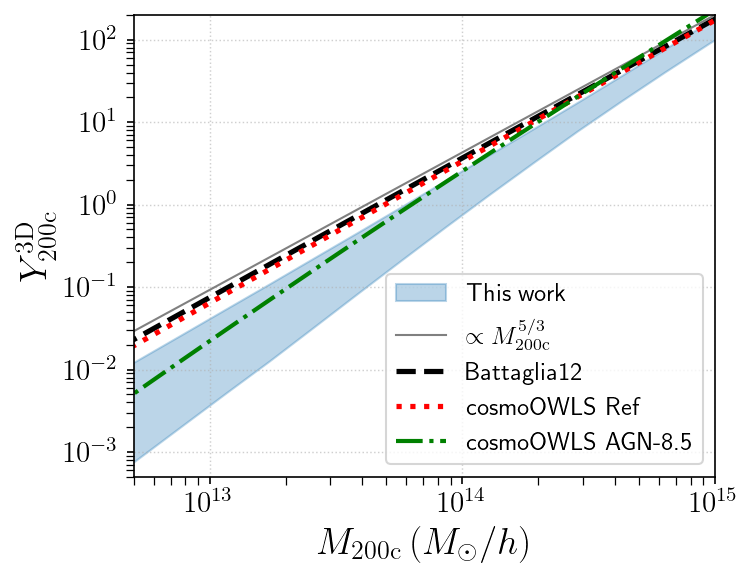

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This work')
# plt.fill_between(M_array, Ymin2, Ymax2, alpha=0.3, color='tab:blue', label='no PS mask')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
plt.plot(M_array, 2e-23*(M_array)**(5/3.), label=r'$\propto M_{\rm 200c}^{5/3}$', lw=1.0, color='gray', ls='-')
plt.plot(M_array, Y_B12_all, label=r'Battaglia12', lw=2.5, color='black', ls='--')
plt.plot(M_array, Y_owls_all_ref, label=r'cosmoOWLS Ref', lw=2.5, color='red', ls=':')
plt.plot(M_array, Y_owls_all_agn, label=r'cosmoOWLS AGN-8.5', lw=2, color='green', ls='-.')

# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$M_{\rm 200c} \, (M_{\odot}/h)$', fontsize=18)
plt.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=18)

# Improved axis limits
plt.xlim(5e12, 1e15)
plt.ylim(5e-4, 2e2)

# Improved legend with frame and better positioning
plt.legend(fontsize=12, frameon=True, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
plt.savefig(sdir + 'YM_v12.pdf', bbox_inches='tight', dpi=300)

plt.show()




Array([1.46779927e-06, 2.86102557e-06, 5.57669396e-06, 1.08700586e-05,
       2.11878533e-05, 4.12992371e-05, 8.05002263e-05, 1.56910561e-04,
       3.05849128e-04, 5.96159294e-04, 1.16203014e-03, 2.26502220e-03,
       4.41496776e-03, 8.60562879e-03, 1.67740403e-02, 3.26958591e-02,
       6.37305734e-02, 1.24223253e-01, 2.42135223e-01, 4.71968532e-01,
       9.19958245e-01, 1.79317712e+00, 3.49525013e+00, 6.81292069e+00],      dtype=float64)

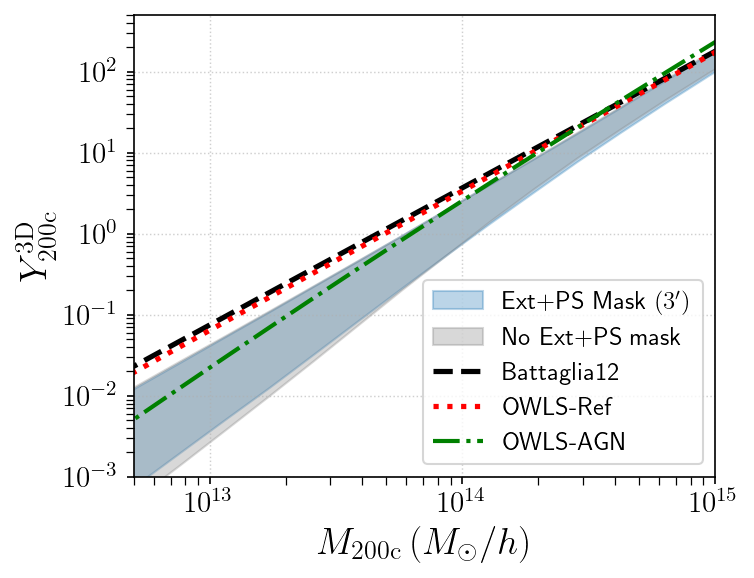

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
# r"Ext+PS Mask $(3')$",r'No Ext+PS mask'
plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label=r"Ext+PS Mask $(3')$")
plt.fill_between(M_array, Ymin2, Ymax2, alpha=0.3, color='tab:gray', label=r'No Ext+PS mask')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
plt.plot(M_array, Y_B12_all, label=r'Battaglia12', lw=2.5, color='black', ls='--')
plt.plot(M_array, Y_owls_all_ref, label=r'OWLS-Ref', lw=2.5, color='red', ls=':')
plt.plot(M_array, Y_owls_all_agn, label=r'OWLS-AGN', lw=2, color='green', ls='-.')

# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$M_{\rm 200c} \, (M_{\odot}/h)$', fontsize=18)
plt.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=18)

# Improved axis limits
plt.xlim(5e12, 1e15)
plt.ylim(1e-3, 5e2)

# Improved legend with frame and better positioning
plt.legend(fontsize=12, frameon=True, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
plt.savefig(sdir + 'YM_v12_comp_maskPS.pdf', bbox_inches='tight', dpi=300)

plt.show()



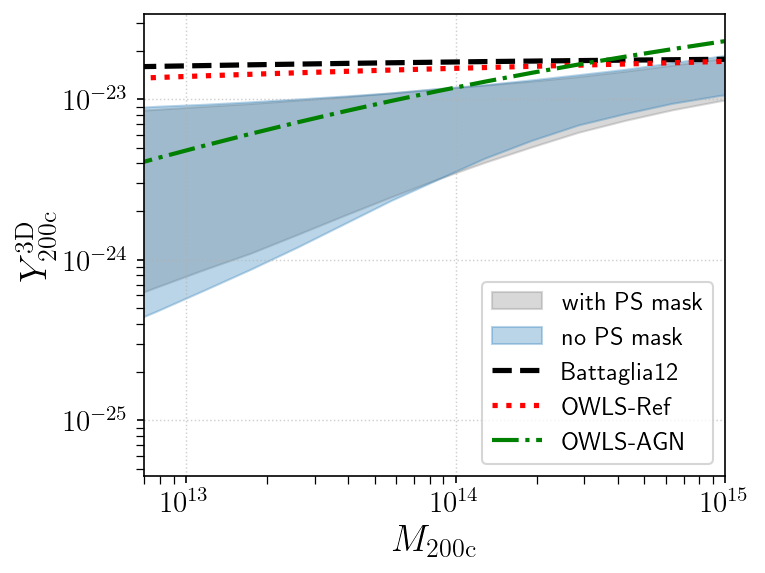

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
plt.fill_between(M_array, Ymin/(M_array**(5/3)), Ymax/(M_array**(5/3)), alpha=0.3, color='tab:gray', label='with PS mask')
plt.fill_between(M_array, Ymin2/(M_array**(5/3)), Ymax2/(M_array**(5/3)), alpha=0.3, color='tab:blue', label='no PS mask')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
plt.plot(M_array, Y_B12_all/(M_array**(5/3)), label=r'Battaglia12', lw=2.5, color='black', ls='--')
plt.plot(M_array, Y_owls_all_ref/(M_array**(5/3)), label=r'OWLS-Ref', lw=2.5, color='red', ls=':')
plt.plot(M_array, Y_owls_all_agn/(M_array**(5/3)), label=r'OWLS-AGN', lw=2, color='green', ls='-.')

# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$M_{\rm 200c}$', fontsize=18)
plt.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=18)

# Improved axis limits
plt.xlim(7e12, 1e15)
# plt.ylim(1e-3, 5e2)

# Improved legend with frame and better positioning
plt.legend(fontsize=12, frameon=True, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'YM_v10_widemuej.pdf', bbox_inches='tight', dpi=300)

plt.show()



In [8]:
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plot_data/YM_plot_data_nsamps_6000_v11_all_probes_widemuej.pkl','rb')) 
# # df.keys()
# M_array = df['M_array']
# Ymin = df['Ymin']
# Ymax = df['Ymax']


In [9]:
# owls_test.get_params_pressure('P0', 20, 0)



In [10]:
# owls_test.r200c_mat[20,0]
# owls_test.r_array


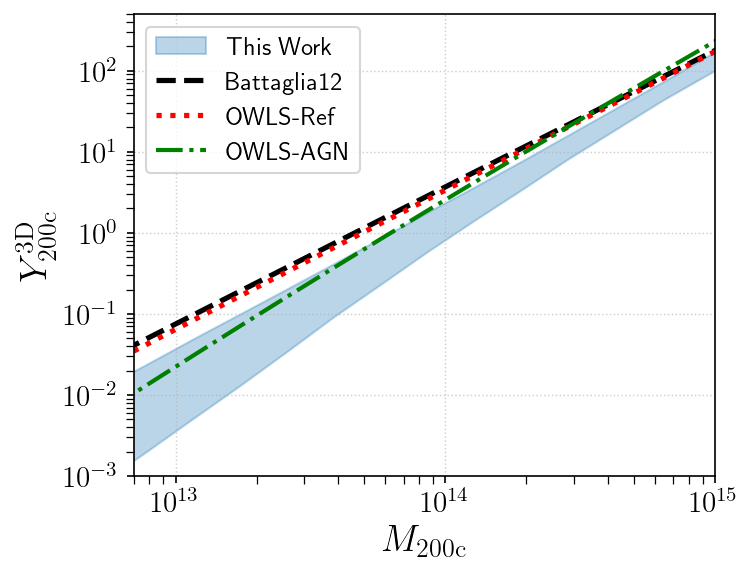

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This Work')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
plt.plot(M_array, Y_B12_all, label=r'Battaglia12', lw=2.5, color='black', ls='--')
plt.plot(M_array, Y_owls_all_ref, label=r'OWLS-Ref', lw=2.5, color='red', ls=':')
plt.plot(M_array, Y_owls_all_agn, label=r'OWLS-AGN', lw=2, color='green', ls='-.')

# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$M_{\rm 200c}$', fontsize=18)
plt.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=18)

# Improved axis limits
plt.xlim(7e12, 1e15)
plt.ylim(1e-3, 5e2)

# Improved legend with frame and better positioning
plt.legend(fontsize=12, frameon=True, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'YM_v10_widemuej.pdf', bbox_inches='tight', dpi=300)

plt.show()



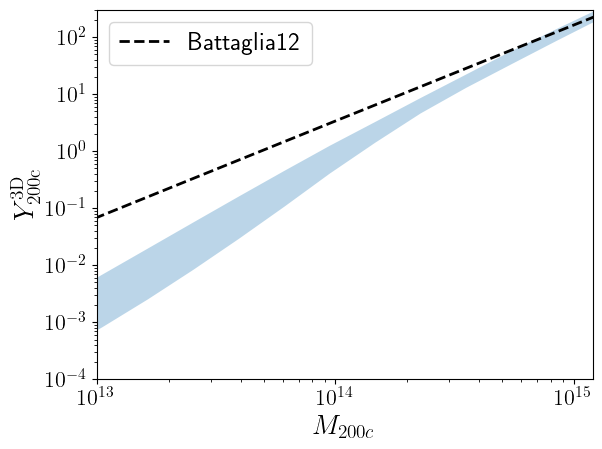

In [35]:
pl.figure()
pl.fill_between(M_array, Ymin, Ymax, alpha=0.3)
pl.plot(M_array, Y_B12_all, label=r'Battaglia12', lw=2.0, color='k', ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-4, 3e2)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/'
pl.savefig(sdir + 'YM.pdf', bbox_inches='tight', dpi=300)

pl.show()



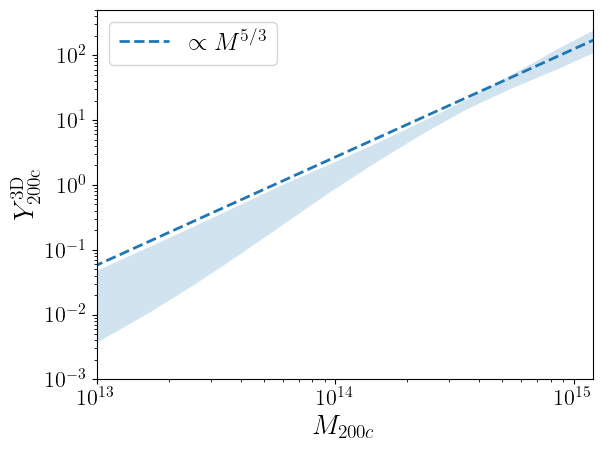

In [26]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(M_array, Ymin, Ymax, alpha=0.2)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
pl.plot(M_array, 1.25e-23 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 5e2)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/'
# pl.savefig(sdir + 'YM.pdf', bbox_inches='tight', dpi=300)

pl.show()



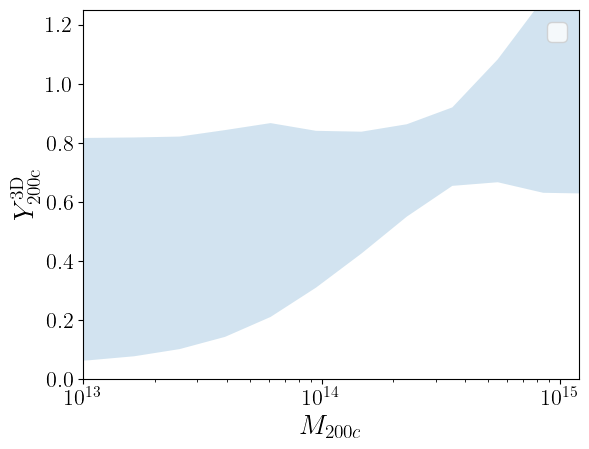

In [28]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(M_array, Ymin/(1.25e-23 * (M_array**(5/3.))), Ymax/(1.25e-23 * (M_array**(5/3.))), alpha=0.2)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
# pl.plot(M_array, 1.25e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
# pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(0,1.25)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()



In [25]:
# B12_test.Pe_mat_physical


/tmp/ipykernel_3746232/3534550581.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))


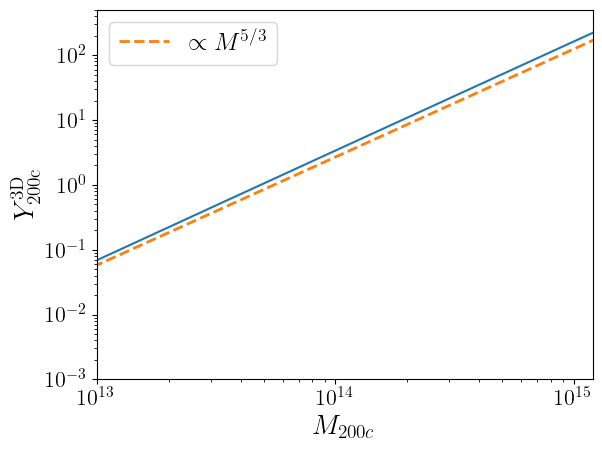

In [11]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
# pl.fill_between(M_array, Ymin, Ymax, alpha=0.2)
pl.plot(M_array, Y_model_all)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
pl.plot(M_array, 1.25e-23 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 5e2)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/'
# pl.savefig(sdir + 'YM.pdf', bbox_inches='tight', dpi=300)

pl.show()

